In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

# Visualization settings
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cwurData.csv to cwurData.csv


In [ ]:
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2200
Columns: 14


In [ ]:
df.columns.tolist()

['world_rank',
 'institution',
 'country',
 'national_rank',
 'quality_of_education',
 'alumni_employment',
 'quality_of_faculty',
 'publications',
 'influence',
 'citations',
 'broad_impact',
 'patents',
 'score',
 'year']

In [ ]:
df.head(10)

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012
5,6,Princeton University,USA,5,8,14,2,53,33,26,NaN,101,82.50,2012
6,7,University of Oxford,United Kingdom,2,13,28,9,15,13,19,NaN,26,82.34,2012
7,8,Yale University,USA,6,14,31,12,14,6,15,NaN,66,79.14,2012
8,9,Columbia University,USA,7,23,21,10,13,12,14,NaN,5,78.86,2012
9,10,"University of California, Berkeley",USA,8,16,52,6,6,5,3,NaN,16,78.55,2012


In [ ]:
df.sample(10)

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
1800,601,Tata Institute of Fundamental Research,India,7,367,567,218,468,450,368,540.0,792,44.51,2015
2180,981,University of Limerick,Ireland,8,367,529,218,892,863,812,969.0,516,44.05,2015
35,36,University of North Carolina at Chapel Hill,USA,25,101,86,56,31,29,31,NaN,29,53.09,2012
1621,422,Chonbuk National University,South Korea,13,367,567,218,507,774,812,646.0,83,45.09,2015
1910,711,Royal College of Surgeons in Ireland,Ireland,5,367,567,218,888,714,368,646.0,446,44.35,2015
1197,998,Shaanxi Normal University,China,82,355,478,210,956,965,800,994.0,737,44.23,2014
1126,927,University of Basilicata,Italy,47,355,478,210,938,886,609,874.0,737,44.36,2014
2090,891,University of Calcutta,India,14,140,346,209,964,900,645,994.0,424,44.14,2015
2155,956,Shiraz University,Iran,7,367,567,218,865,962,645,921.0,871,44.07,2015
200,1,Harvard University,USA,1,1,1,1,1,1,1,1.0,2,100.00,2014


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   world_rank            2200 non-null   int64  
 1   institution           2200 non-null   object 
 2   country               2200 non-null   object 
 3   national_rank         2200 non-null   int64  
 4   quality_of_education  2200 non-null   int64  
 5   alumni_employment     2200 non-null   int64  
 6   quality_of_faculty    2200 non-null   int64  
 7   publications          2200 non-null   int64  
 8   influence             2200 non-null   int64  
 9   citations             2200 non-null   int64  
 10  broad_impact          2000 non-null   float64
 11  patents               2200 non-null   int64  
 12  score                 2200 non-null   float64
 13  year                  2200 non-null   int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 240.8+ KB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
world_rank,2200.0,NaN,NaN,NaN,459.590909,304.320363,1.0,175.75,450.5,725.25,1000.0
institution,2200,1024,University of Cambridge,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2200,59,USA,573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
national_rank,2200.0,NaN,NaN,NaN,40.278182,51.74087,1.0,6.0,21.0,49.0,229.0
quality_of_education,2200.0,NaN,NaN,NaN,275.100455,121.9351,1.0,175.75,355.0,367.0,367.0
alumni_employment,2200.0,NaN,NaN,NaN,357.116818,186.779252,1.0,175.75,450.5,478.0,567.0
quality_of_faculty,2200.0,NaN,NaN,NaN,178.888182,64.050885,1.0,175.75,210.0,218.0,218.0
publications,2200.0,NaN,NaN,NaN,459.908636,303.760352,1.0,175.75,450.5,725.0,1000.0
influence,2200.0,NaN,NaN,NaN,459.797727,303.331822,1.0,175.75,450.5,725.25,991.0
citations,2200.0,NaN,NaN,NaN,413.417273,264.366549,1.0,161.0,406.0,645.0,812.0


In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("Missing %", ascending=False)

,Missing Values,Missing %
broad_impact,200,9.090909
world_rank,0,0.000000
country,0,0.000000
national_rank,0,0.000000
quality_of_education,0,0.000000
institution,0,0.000000
alumni_employment,0,0.000000
quality_of_faculty,0,0.000000
influence,0,0.000000
publications,0,0.000000


In [ ]:
df[df["broad_impact"].isna()].head(20)

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012
5,6,Princeton University,USA,5,8,14,2,53,33,26,NaN,101,82.50,2012
6,7,University of Oxford,United Kingdom,2,13,28,9,15,13,19,NaN,26,82.34,2012
7,8,Yale University,USA,6,14,31,12,14,6,15,NaN,66,79.14,2012
8,9,Columbia University,USA,7,23,21,10,13,12,14,NaN,5,78.86,2012
9,10,"University of California, Berkeley",USA,8,16,52,6,6,5,3,NaN,16,78.55,2012


In [ ]:
# Create a flag showing whether broad_impact is missing
df["broad_impact_missing"] = df["broad_impact"].isna()

# Compare rows where broad_impact is missing vs available
df.groupby("broad_impact_missing")[
    ["world_rank", "score", "year"]
].agg(["count", "mean", "min", "max"])

world_rank                  score                   \
                          count   mean min   max count      mean    min   
broad_impact_missing                                                      
False                      2000  500.5   1  1000  2000  47.06763  44.02   
True                        200   50.5   1   100   200  55.10605  43.36   

                             year                      
                        max count    mean   min   max  
broad_impact_missing                                   
False                 100.0  2000  2014.5  2014  2015  
True                  100.0   200  2012.5  2012  2013

In [ ]:
df[df["broad_impact"].isna()][
    [
        "institution",
        "country",
        "world_rank",
        "score",
        "year",
        "broad_impact"
    ]
].head(20)

,institution,country,world_rank,score,year,broad_impact
0,Harvard University,USA,1,100.00,2012,NaN
1,Massachusetts Institute of Technology,USA,2,91.67,2012,NaN
2,Stanford University,USA,3,89.50,2012,NaN
3,University of Cambridge,United Kingdom,4,86.17,2012,NaN
4,California Institute of Technology,USA,5,85.21,2012,NaN
5,Princeton University,USA,6,82.50,2012,NaN
6,University of Oxford,United Kingdom,7,82.34,2012,NaN
7,Yale University,USA,8,79.14,2012,NaN
8,Columbia University,USA,9,78.86,2012,NaN
9,"University of California, Berkeley",USA,10,78.55,2012,NaN


In [ ]:
df.groupby("year")["broad_impact"].apply(
    lambda x: x.isna().sum()
).reset_index(name="missing_broad_impact")

,year,missing_broad_impact
0,2012,100
1,2013,100
2,2014,0
3,2015,0


In [ ]:
df.drop(columns=["broad_impact_missing"], inplace=True)

In [ ]:
df.columns

Index(['world_rank', 'institution', 'country', 'national_rank',
       'quality_of_education', 'alumni_employment', 'quality_of_faculty',
       'publications', 'influence', 'citations', 'broad_impact', 'patents',
       'score', 'year'],
      dtype='object')

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
duplicate_university_year = df.duplicated(
    subset=["institution", "year"]
).sum()

print(
    "Duplicate institution-year combinations:",
    duplicate_university_year
)

Duplicate institution-year combinations: 0


In [ ]:
year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

year_counts.columns = ["year", "universities"]

year_counts

,year,universities
0,2012,100
1,2013,100
2,2014,1000
3,2015,1000


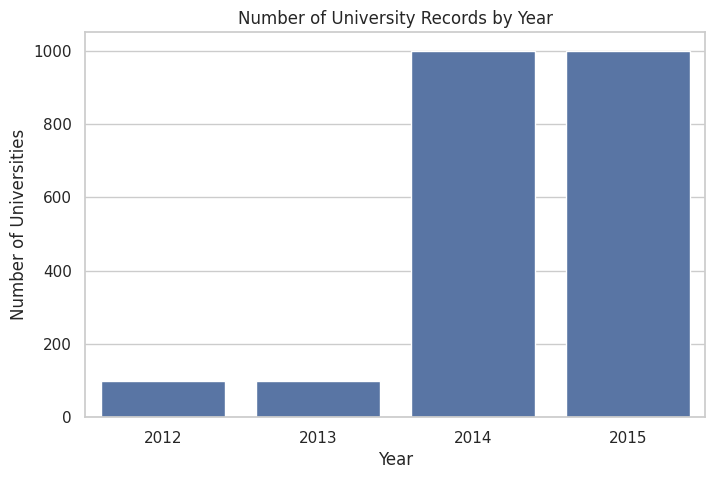

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=year_counts,
    x="year",
    y="universities"
)

plt.title("Number of University Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Universities")

plt.show()

In [ ]:
# 📊 Exploratory Data Analysis (EDA)

The objective of this section is to explore the structure,
distribution, trends, and relationships within the global
university ranking dataset.

The analysis focuses on university rankings, countries,
performance indicators, and changes across years.

In [ ]:
print("Number of Universities/Records:", df.shape[0])
print("Number of Features:", df.shape[1])

print("\nYears covered:", sorted(df["year"].unique()))

print("\nNumber of Countries:", df["country"].nunique())

print("\nNumber of Institutions:", df["institution"].nunique())

Number of Universities/Records: 2200
Number of Features: 14

Years covered: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]

Number of Countries: 59

Number of Institutions: 1024


In [ ]:
df.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012


In [ ]:
year_counts = (
    df.groupby("year")["institution"]
      .nunique()
      .reset_index(name="university_count")
)

year_counts

,year,university_count
0,2012,100
1,2013,100
2,2014,1000
3,2015,1000


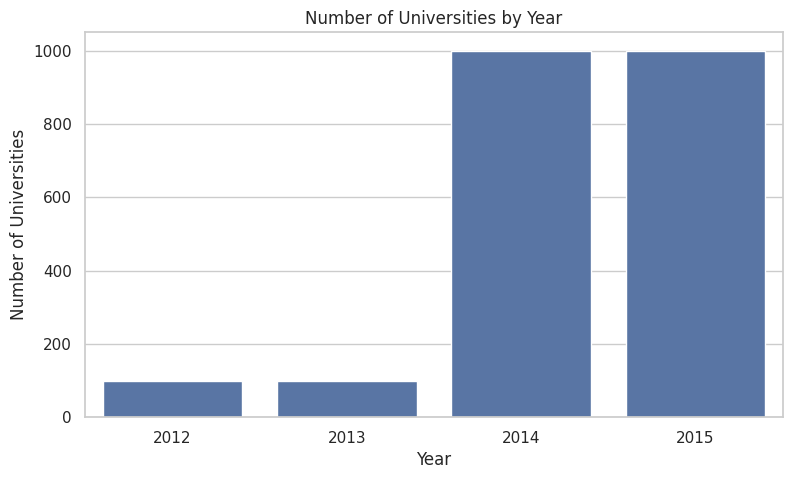

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=year_counts,
    x="year",
    y="university_count"
)

plt.title("Number of Universities by Year")
plt.xlabel("Year")
plt.ylabel("Number of Universities")

plt.show()

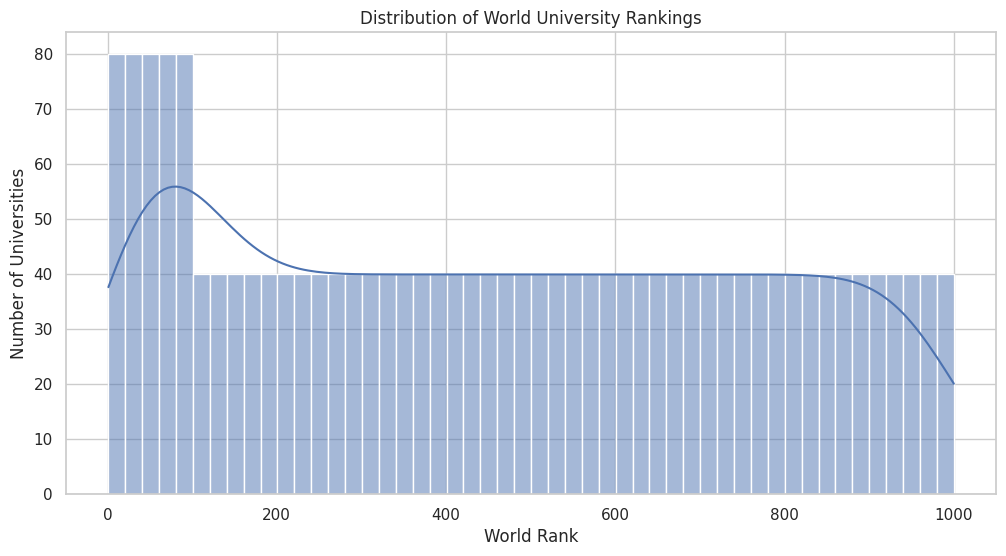

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="world_rank",
    bins=50,
    kde=True
)

plt.title("Distribution of World University Rankings")
plt.xlabel("World Rank")
plt.ylabel("Number of Universities")

plt.show()

In [ ]:
top20 = (
    df.sort_values("world_rank")
      .head(20)
)

top20[
    ["world_rank", "institution", "country", "year"]
]

,world_rank,institution,country,year
100,1,Harvard University,USA,2013
1200,1,Harvard University,USA,2015
200,1,Harvard University,USA,2014
0,1,Harvard University,USA,2012
1201,2,Stanford University,USA,2015
201,2,Stanford University,USA,2014
1,2,Massachusetts Institute of Technology,USA,2012
101,2,Stanford University,USA,2013
2,3,Stanford University,USA,2012
202,3,Massachusetts Institute of Technology,USA,2014


plt.figure(figsize=(12, 8))

sns.barplot(
    data=top20,
    x="world_rank",
    y="institution"
)

plt.title("Top 20 Universities by World Rank")
plt.xlabel("World Rank")
plt.ylabel("University")

plt.show()

In [ ]:
country_counts = (
    df["country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = [
    "country",
    "university_count"
]

country_counts.head(20)

,country,university_count
0,USA,573
1,China,167
2,Japan,159
3,United Kingdom,144
4,Germany,115
5,France,109
6,Italy,96
7,Spain,81
8,Canada,72
9,South Korea,72


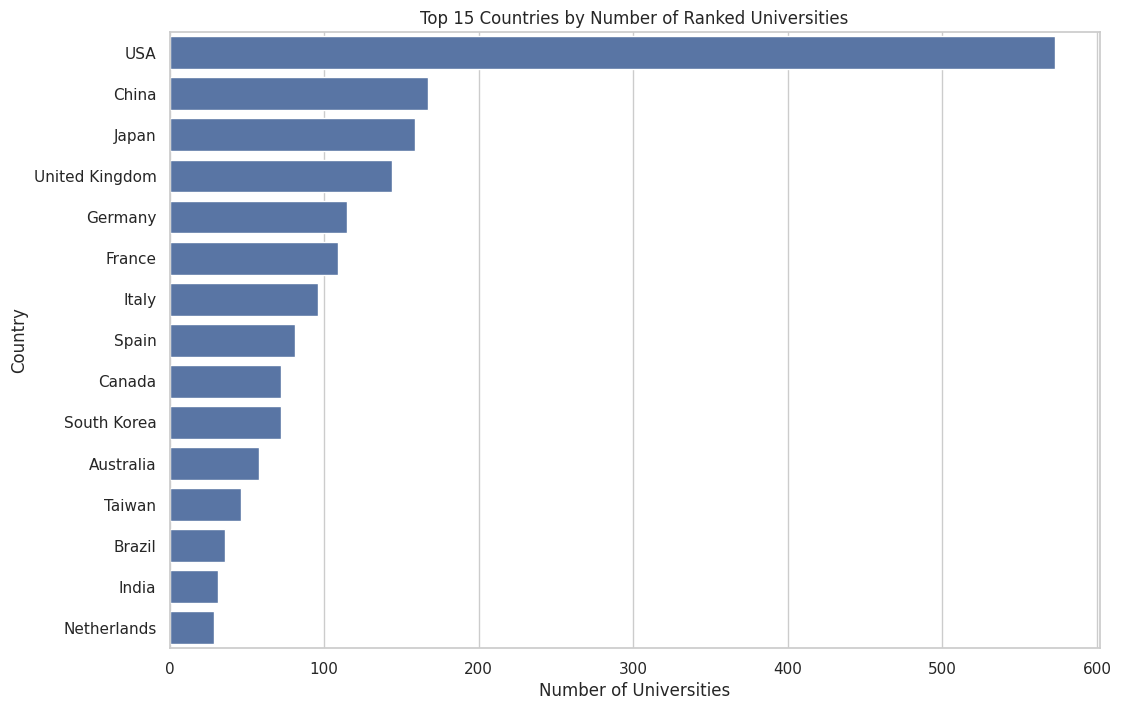

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=country_counts.head(15),
    x="university_count",
    y="country"
)

plt.title("Top 15 Countries by Number of Ranked Universities")
plt.xlabel("Number of Universities")
plt.ylabel("Country")

plt.show()

In [ ]:
top100 = df[df["world_rank"] <= 100]

top100_country_counts = (
    top100["country"]
    .value_counts()
    .reset_index()
)

top100_country_counts.columns = [
    "country",
    "top100_count"
]

top100_country_counts

,country,top100_count
0,USA,223
1,United Kingdom,29
2,Japan,26
3,France,18
4,Switzerland,16
5,Israel,14
6,Canada,13
7,Germany,11
8,Australia,8
9,Netherlands,6


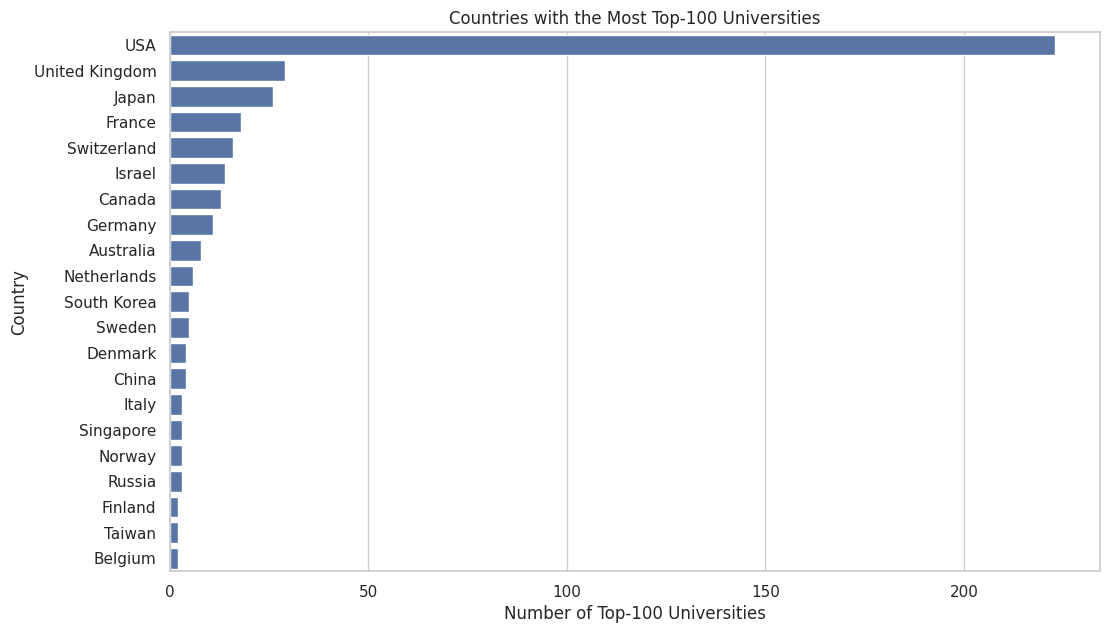

In [ ]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top100_country_counts,
    x="top100_count",
    y="country"
)

plt.title("Countries with the Most Top-100 Universities")
plt.xlabel("Number of Top-100 Universities")
plt.ylabel("Country")

plt.show()

In [ ]:
country_performance = (
    df.groupby("country")
      .agg(
          university_count=("institution", "nunique"),
          average_world_rank=("world_rank", "mean"),
          best_world_rank=("world_rank", "min")
      )
      .reset_index()
)

country_performance.sort_values(
    "average_world_rank"
).head(20)

,country,university_count,average_world_rank,best_world_rank
43,Singapore,2,101.800000,65
26,Israel,7,181.590909,18
50,Switzerland,9,182.038462,16
33,Netherlands,13,216.862069,84
13,Denmark,5,232.666667,68
49,Sweden,11,246.458333,60
54,USA,231,290.528796,1
20,Hong Kong,6,347.250000,155
35,Norway,5,347.250000,81
46,South Africa,5,361.900000,114


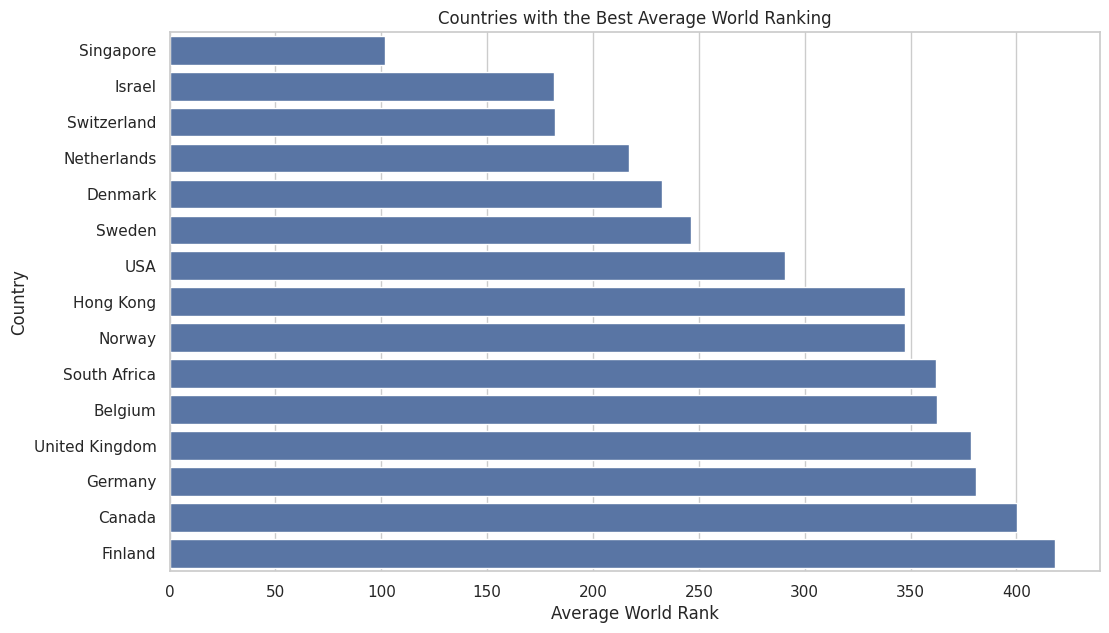

In [ ]:
top_countries = (
    country_performance
    .sort_values("average_world_rank")
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_countries,
    x="average_world_rank",
    y="country"
)

plt.title("Countries with the Best Average World Ranking")
plt.xlabel("Average World Rank")
plt.ylabel("Country")

plt.show()

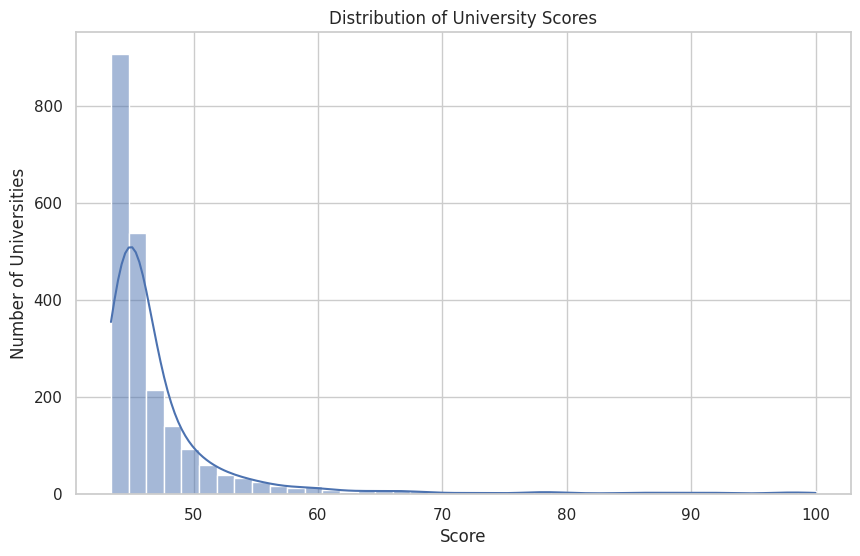

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="score",
    bins=40,
    kde=True
)

plt.title("Distribution of University Scores")
plt.xlabel("Score")
plt.ylabel("Number of Universities")

plt.show()

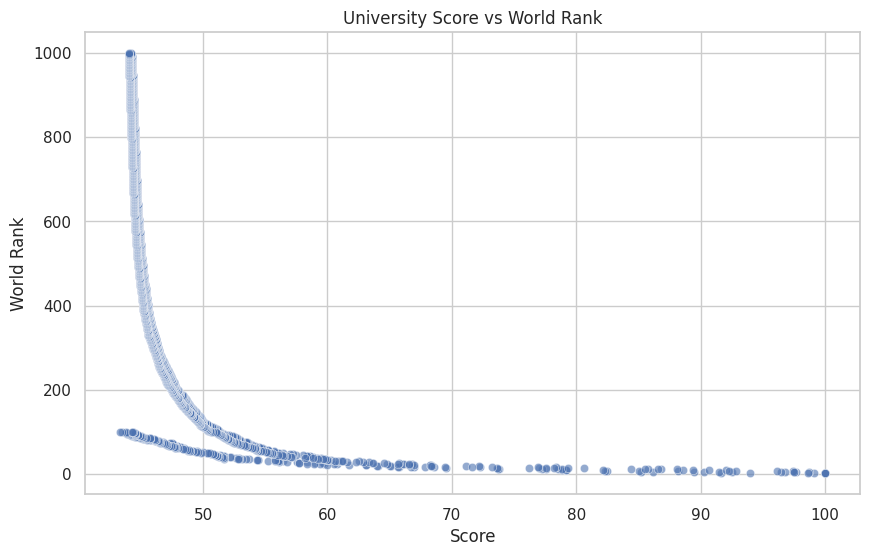

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="score",
    y="world_rank",
    alpha=0.6
)

plt.title("University Score vs World Rank")
plt.xlabel("Score")
plt.ylabel("World Rank")

plt.show()

In [ ]:
year_score = (
    df.groupby("year")["score"]
      .mean()
      .reset_index()
)

year_score

,year,score
0,2012,54.94090
1,2013,55.27120
2,2014,47.27141
3,2015,46.86385


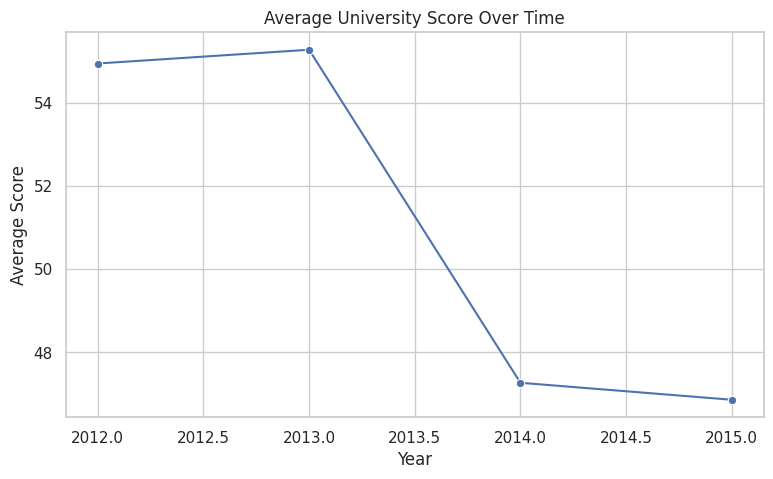

In [ ]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=year_score,
    x="year",
    y="score",
    marker="o"
)

plt.title("Average University Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average Score")

plt.show()

In [ ]:
year_rank = (
    df.groupby("year")["world_rank"]
      .mean()
      .reset_index()
)

year_rank

,year,world_rank
0,2012,50.5
1,2013,50.5
2,2014,500.5
3,2015,500.5


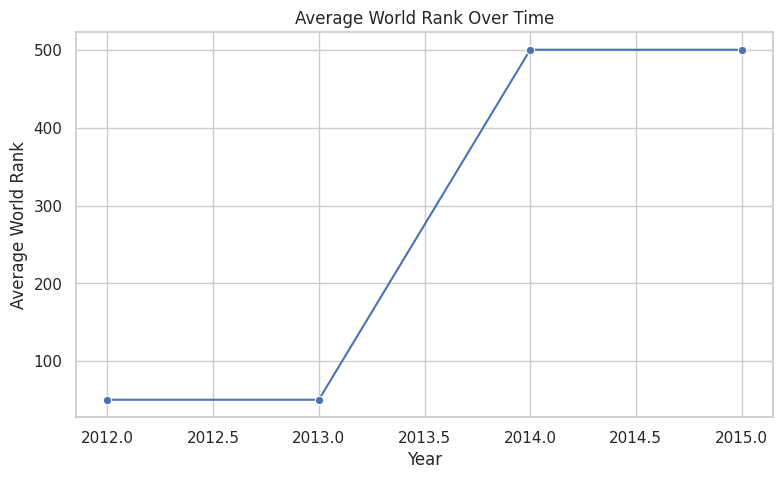

In [ ]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=year_rank,
    x="year",
    y="world_rank",
    marker="o"
)

plt.title("Average World Rank Over Time")
plt.xlabel("Year")
plt.ylabel("Average World Rank")

plt.show()

In [ ]:
ranking_features = [
    "world_rank",
    "national_rank",
    "quality_of_education",
    "alumni_employment",
    "quality_of_faculty",
    "publications",
    "influence",
    "citations",
    "patents",
    "score"
]

correlation = df[ranking_features].corr()

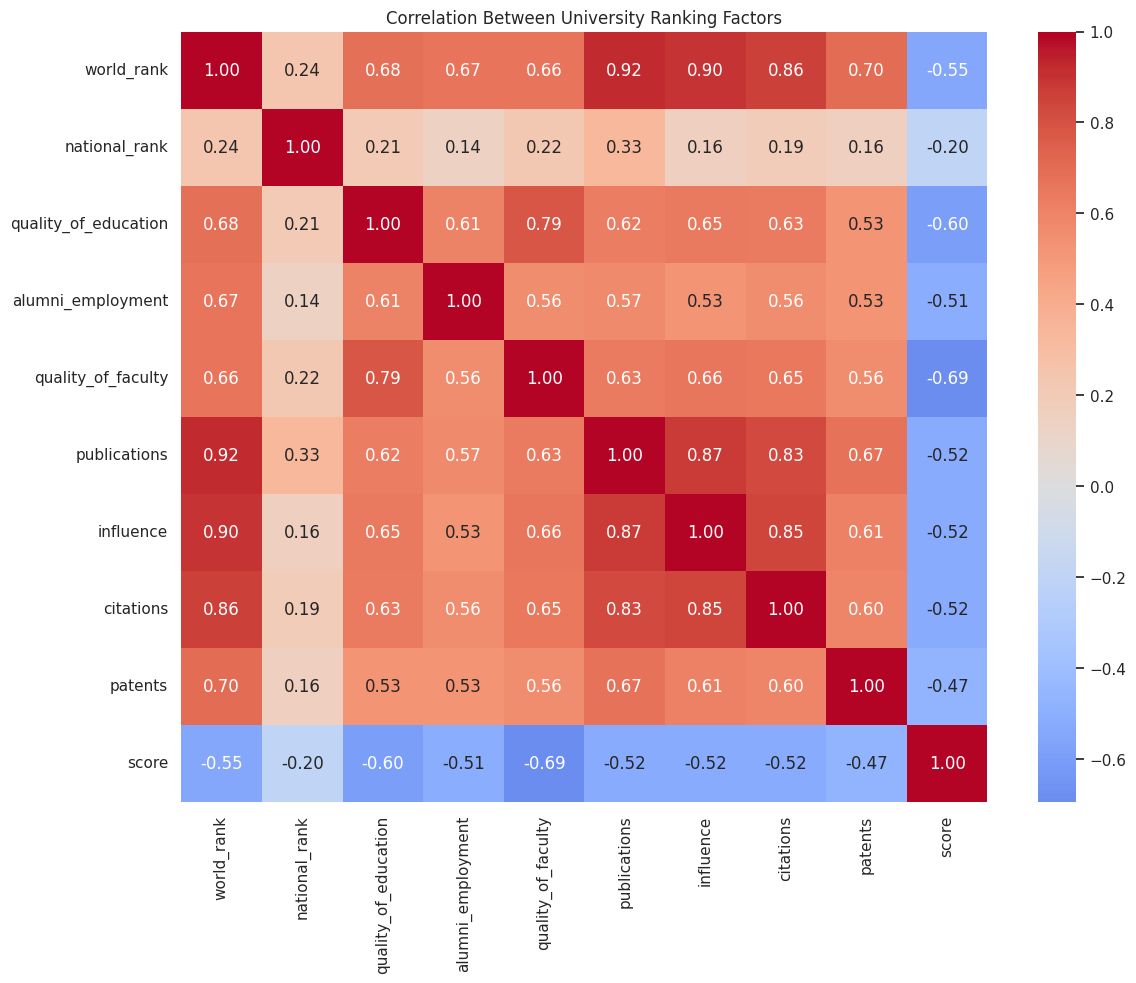

In [ ]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between University Ranking Factors")

plt.show()

In [ ]:
world_rank_corr = (
    correlation["world_rank"]
    .drop("world_rank")
    .sort_values()
)

world_rank_corr

,world_rank
score,-0.549098
national_rank,0.238553
quality_of_faculty,0.663864
alumni_employment,0.668529
quality_of_education,0.676166
patents,0.698214
citations,0.856573
influence,0.895871
publications,0.923037


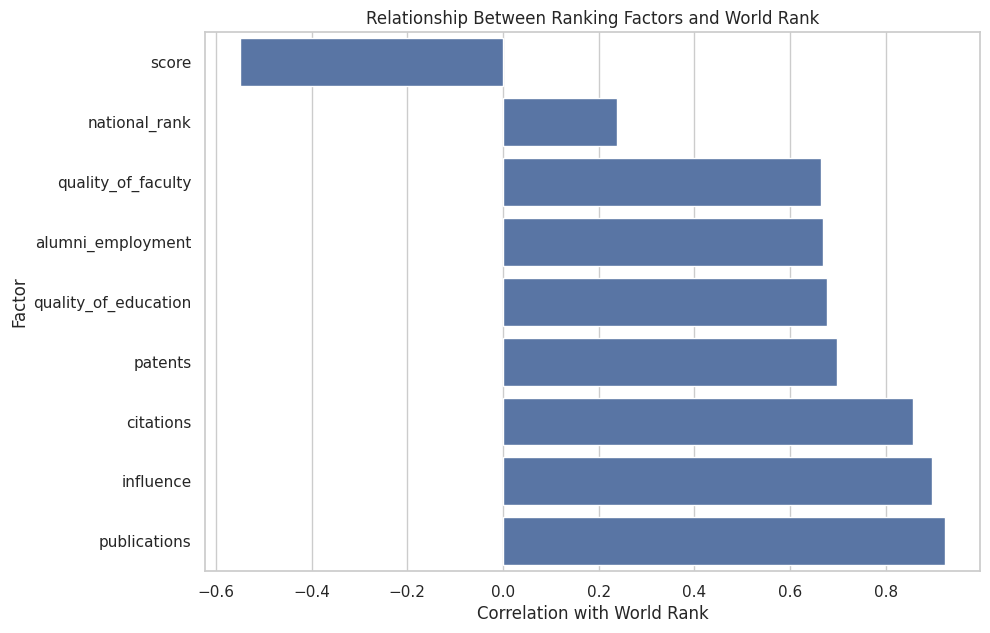

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=world_rank_corr.values,
    y=world_rank_corr.index
)

plt.title("Relationship Between Ranking Factors and World Rank")
plt.xlabel("Correlation with World Rank")
plt.ylabel("Factor")

plt.show()

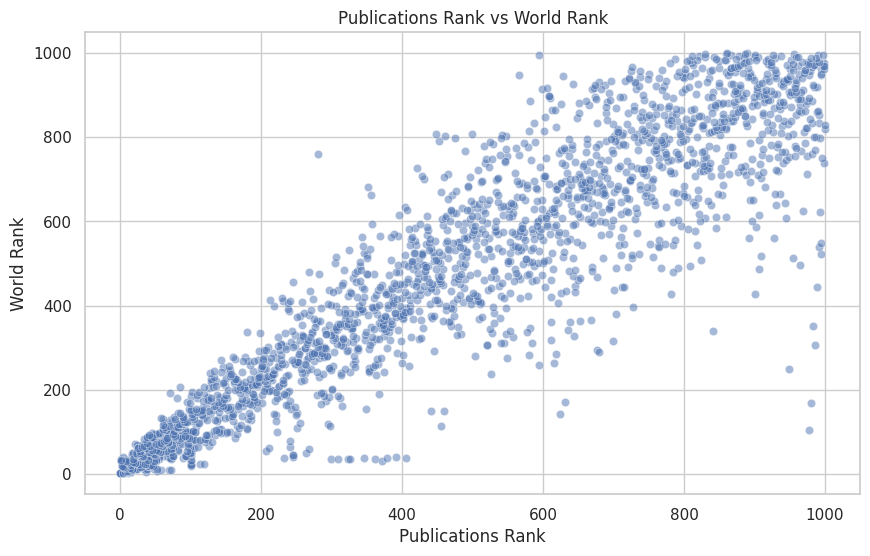

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="publications",
    y="world_rank",
    alpha=0.5
)

plt.title("Publications Rank vs World Rank")
plt.xlabel("Publications Rank")
plt.ylabel("World Rank")

plt.show()

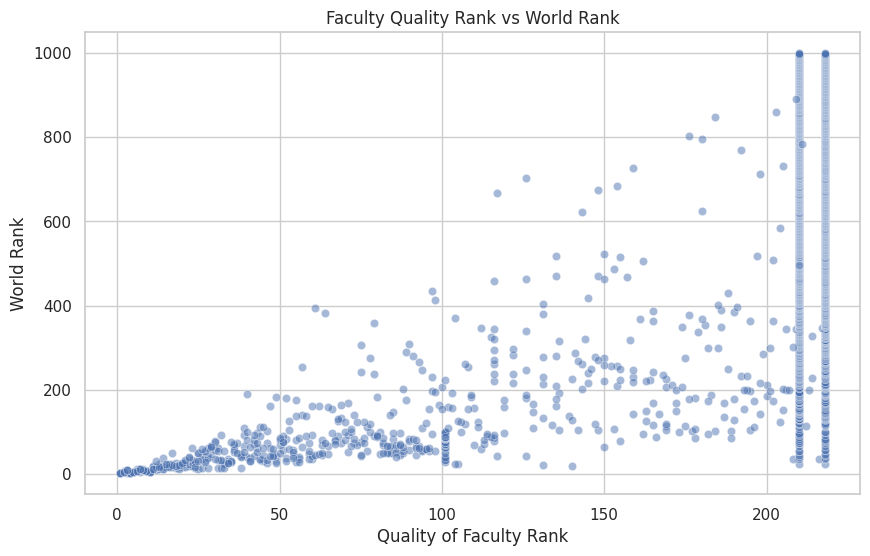

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="quality_of_faculty",
    y="world_rank",
    alpha=0.5
)

plt.title("Faculty Quality Rank vs World Rank")
plt.xlabel("Quality of Faculty Rank")
plt.ylabel("World Rank")

plt.show()

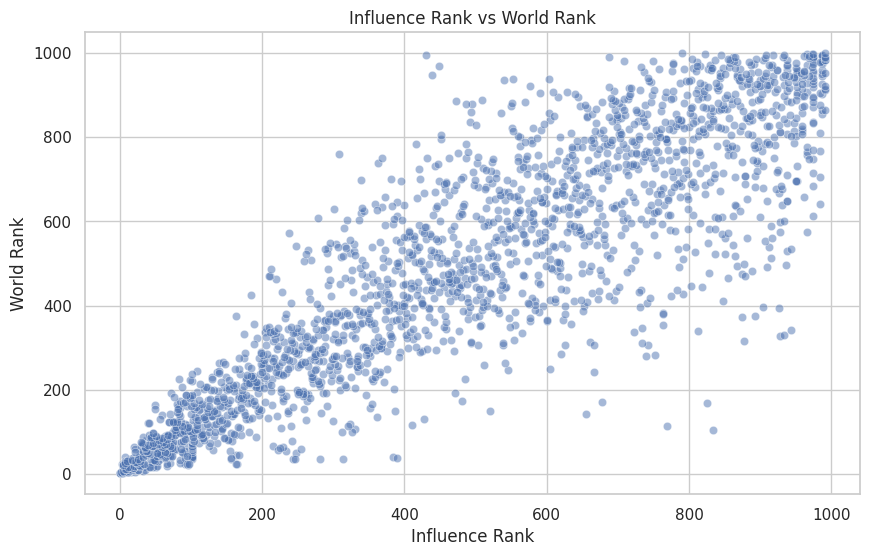

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="influence",
    y="world_rank",
    alpha=0.5
)

plt.title("Influence Rank vs World Rank")
plt.xlabel("Influence Rank")
plt.ylabel("World Rank")

plt.show()

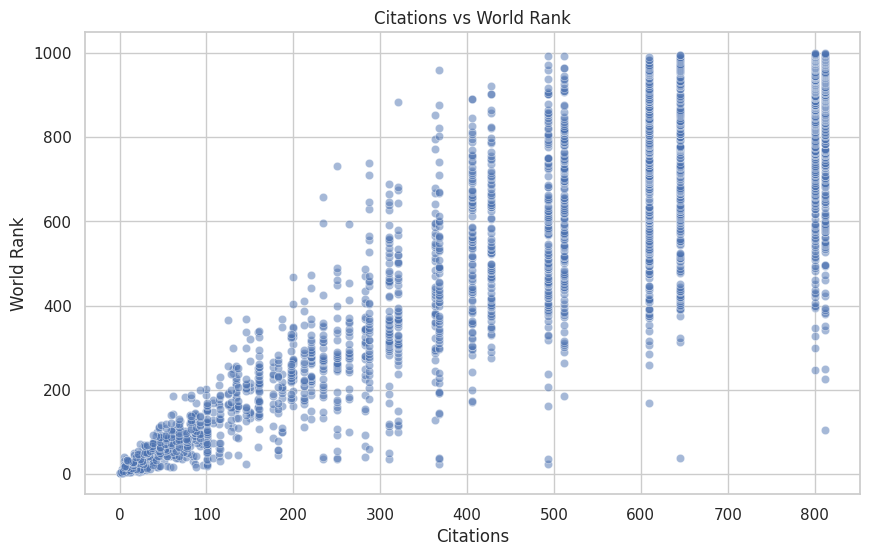

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="citations",
    y="world_rank",
    alpha=0.5
)

plt.title("Citations vs World Rank")
plt.xlabel("Citations")
plt.ylabel("World Rank")

plt.show()

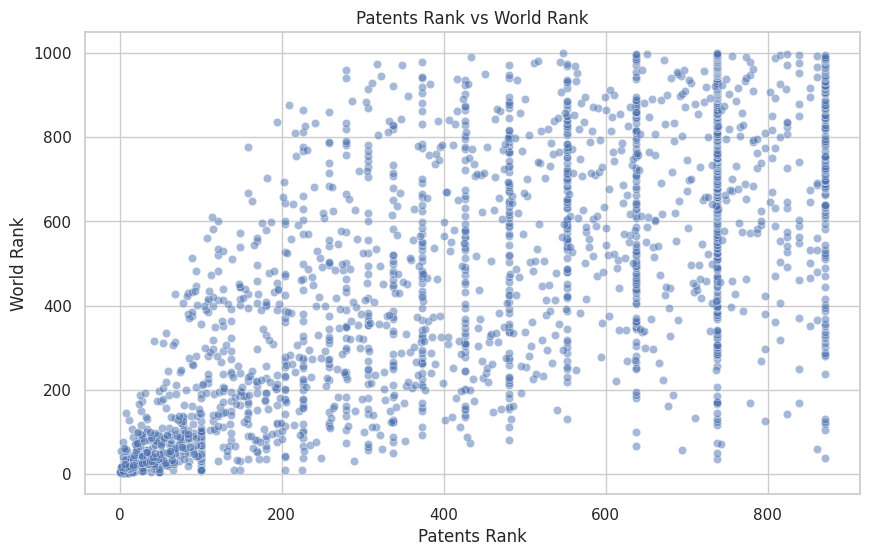

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="patents",
    y="world_rank",
    alpha=0.5
)

plt.title("Patents Rank vs World Rank")
plt.xlabel("Patents Rank")
plt.ylabel("World Rank")

plt.show()

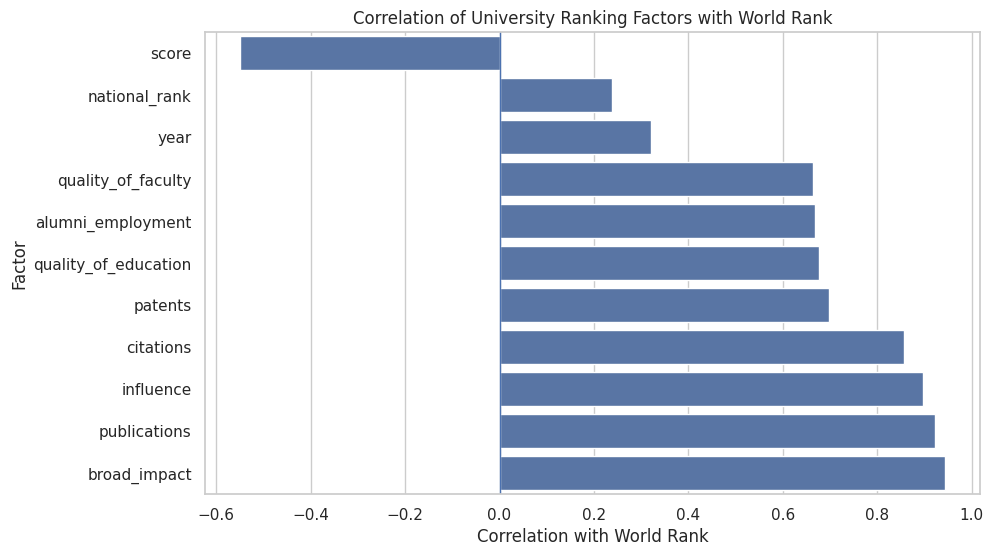

In [ ]:
rank_corr = (
    df.corr(numeric_only=True)["world_rank"]
    .drop("world_rank")
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=rank_corr.values,
    y=rank_corr.index
)

plt.title("Correlation of University Ranking Factors with World Rank")
plt.xlabel("Correlation with World Rank")
plt.ylabel("Factor")

plt.axvline(0, linewidth=1)

plt.show()

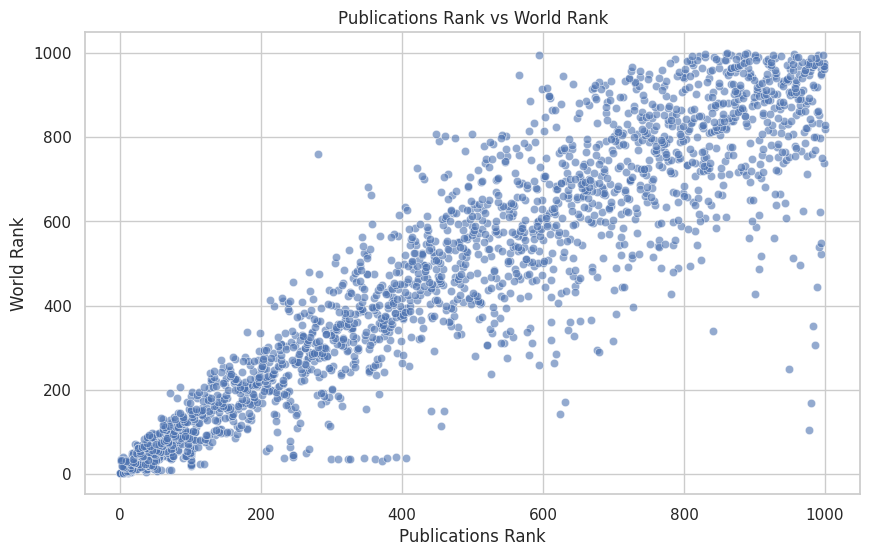

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="publications",
    y="world_rank",
    alpha=0.6
)

plt.title("Publications Rank vs World Rank")
plt.xlabel("Publications Rank")
plt.ylabel("World Rank")

plt.show()

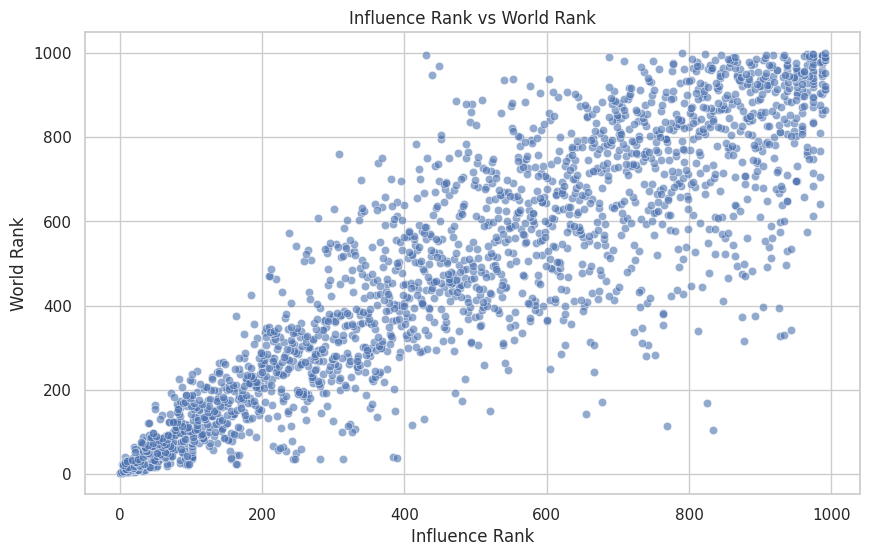

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="influence",
    y="world_rank",
    alpha=0.6
)

plt.title("Influence Rank vs World Rank")
plt.xlabel("Influence Rank")
plt.ylabel("World Rank")

plt.show()

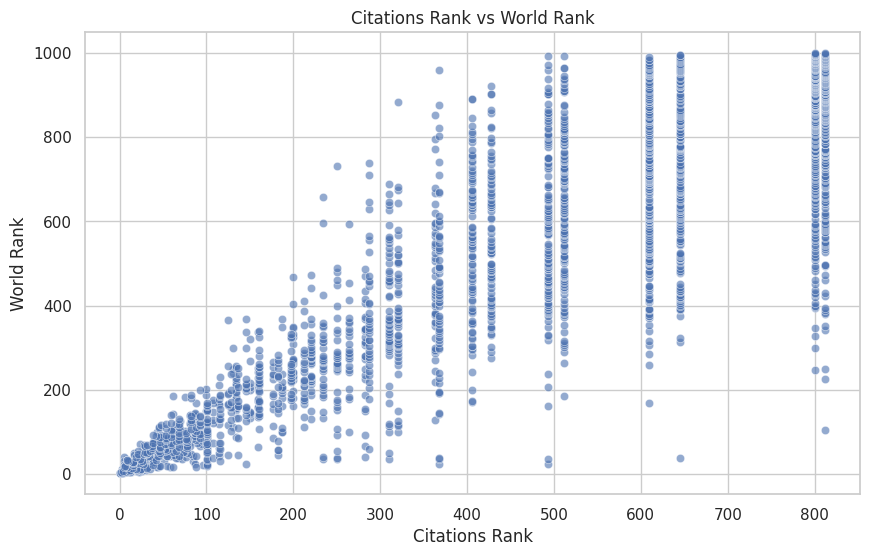

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="citations",
    y="world_rank",
    alpha=0.6
)

plt.title("Citations Rank vs World Rank")
plt.xlabel("Citations Rank")
plt.ylabel("World Rank")

plt.show()

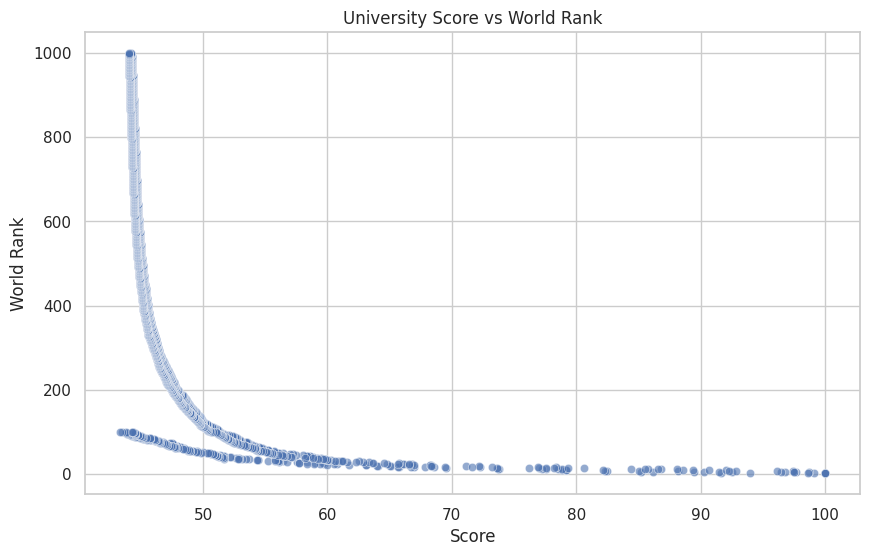

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="score",
    y="world_rank",
    alpha=0.6
)

plt.title("University Score vs World Rank")
plt.xlabel("Score")
plt.ylabel("World Rank")

plt.show()

In [ ]:
ranking_change = (
    df[df["year"].isin([2012, 2015])]
    .pivot_table(
        index="institution",
        columns="year",
        values="world_rank",
        aggfunc="first"
    )
    .dropna()
)

ranking_change["rank_change"] = (
    ranking_change[2012] - ranking_change[2015]
)

ranking_change.sort_values(
    "rank_change",
    ascending=False
).head(20)

year,2012,2015,rank_change
institution,,,
Seoul National University,75.0,24.0,51.0
University of Virginia,84.0,41.0,43.0
University of Pittsburgh - Pittsburgh Campus,71.0,46.0,25.0
École Polytechnique,61.0,36.0,25.0
Rutgers University-New Brunswick,72.0,50.0,22.0
University of Copenhagen,93.0,74.0,19.0
École normale supérieure - Paris,54.0,37.0,17.0
"Pennsylvania State University, University Park",64.0,47.0,17.0
"University of Michigan, Ann Arbor",34.0,19.0,15.0


In [ ]:
ranking_change = (
    df[df["year"].isin([2012, 2015])]
    .pivot_table(
        index="institution",
        columns="year",
        values="world_rank",
        aggfunc="first"
    )
    .dropna()
)

ranking_change["rank_change"] = (
    ranking_change[2012] - ranking_change[2015]
)

ranking_change.sort_values(
    "rank_change",
    ascending=False
).head(20)

year,2012,2015,rank_change
institution,,,
Seoul National University,75.0,24.0,51.0
University of Virginia,84.0,41.0,43.0
University of Pittsburgh - Pittsburgh Campus,71.0,46.0,25.0
École Polytechnique,61.0,36.0,25.0
Rutgers University-New Brunswick,72.0,50.0,22.0
University of Copenhagen,93.0,74.0,19.0
École normale supérieure - Paris,54.0,37.0,17.0
"Pennsylvania State University, University Park",64.0,47.0,17.0
"University of Michigan, Ann Arbor",34.0,19.0,15.0


In [ ]:
ranking_change.sort_values(
    "rank_change",
    ascending=True
).head(20)

year,2012,2015,rank_change
institution,,,
Technion – Israel Institute of Technology,51.0,136.0,-85.0
Rice University,57.0,120.0,-63.0
Nagoya University,74.0,125.0,-51.0
University of Texas Southwestern Medical Center,29.0,75.0,-46.0
University of Nottingham,97.0,140.0,-43.0
"University of California, Irvine",47.0,89.0,-42.0
Sapienza University of Rome,77.0,112.0,-35.0
University of Utah,38.0,70.0,-32.0
Tel Aviv University,56.0,86.0,-30.0


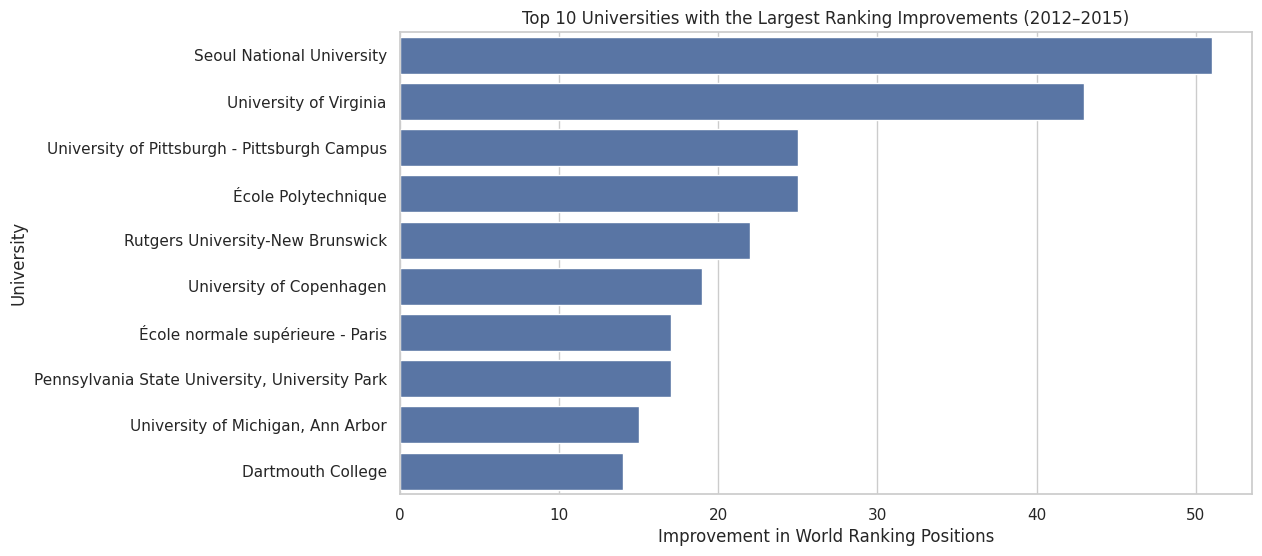

In [ ]:
top_improvers = (
    ranking_change
    .sort_values("rank_change", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_improvers,
    x="rank_change",
    y="institution"
)

plt.title("Top 10 Universities with the Largest Ranking Improvements (2012–2015)")
plt.xlabel("Improvement in World Ranking Positions")
plt.ylabel("University")

plt.show()

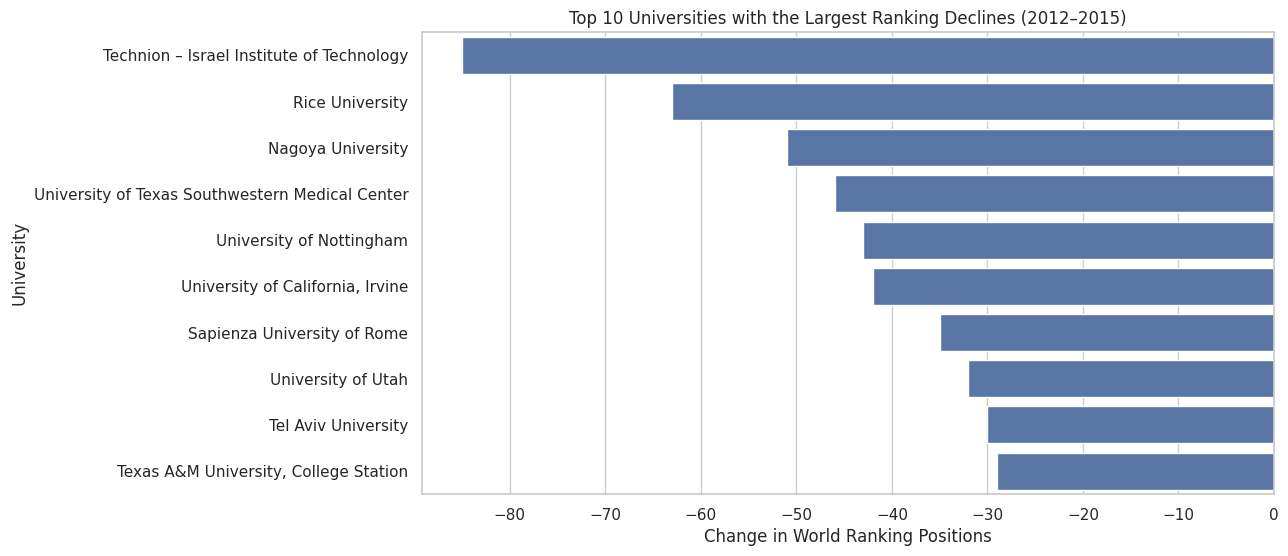

In [ ]:
top_decliners = (
    ranking_change
    .sort_values("rank_change", ascending=True)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_decliners,
    x="rank_change",
    y="institution"
)

plt.title("Top 10 Universities with the Largest Ranking Declines (2012–2015)")
plt.xlabel("Change in World Ranking Positions")
plt.ylabel("University")

plt.show()

In [ ]:
top100_consistency = (
    df[df["world_rank"] <= 100]
    .groupby("institution")["year"]
    .nunique()
    .reset_index(name="years_in_top100")
)

top100_consistency = (
    top100_consistency[
        top100_consistency["years_in_top100"] == df["year"].nunique()
    ]
    .sort_values("institution")
)

top100_consistency

,institution,years_in_top100
2,Boston University,4
3,Brown University,4
4,California Institute of Technology,4
5,Carnegie Mellon University,4
7,Columbia University,4
8,Cornell University,4
9,Dartmouth College,4
10,Duke University,4
11,Emory University,4
13,Georgia Institute of Technology,4


In [ ]:
country_counts = (
    df["country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["country", "university_count"]

country_counts.head(20)

,country,university_count
0,USA,573
1,China,167
2,Japan,159
3,United Kingdom,144
4,Germany,115
5,France,109
6,Italy,96
7,Spain,81
8,Canada,72
9,South Korea,72


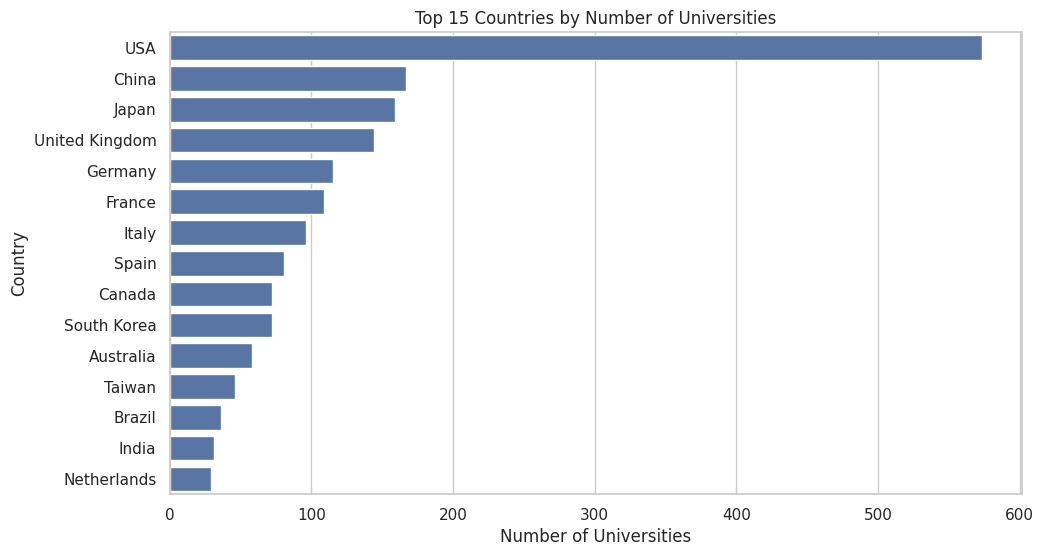

In [ ]:
top_countries = country_counts.head(15)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_countries,
    x="university_count",
    y="country"
)

plt.title("Top 15 Countries by Number of Universities")
plt.xlabel("Number of Universities")
plt.ylabel("Country")

plt.show()

In [ ]:
top100 = df[df["world_rank"] <= 100]

top100_country_counts = (
    top100["country"]
    .value_counts()
    .reset_index()
)

top100_country_counts.columns = ["country", "top100_count"]

top100_country_counts.head(20)

,country,top100_count
0,USA,223
1,United Kingdom,29
2,Japan,26
3,France,18
4,Switzerland,16
5,Israel,14
6,Canada,13
7,Germany,11
8,Australia,8
9,Netherlands,6


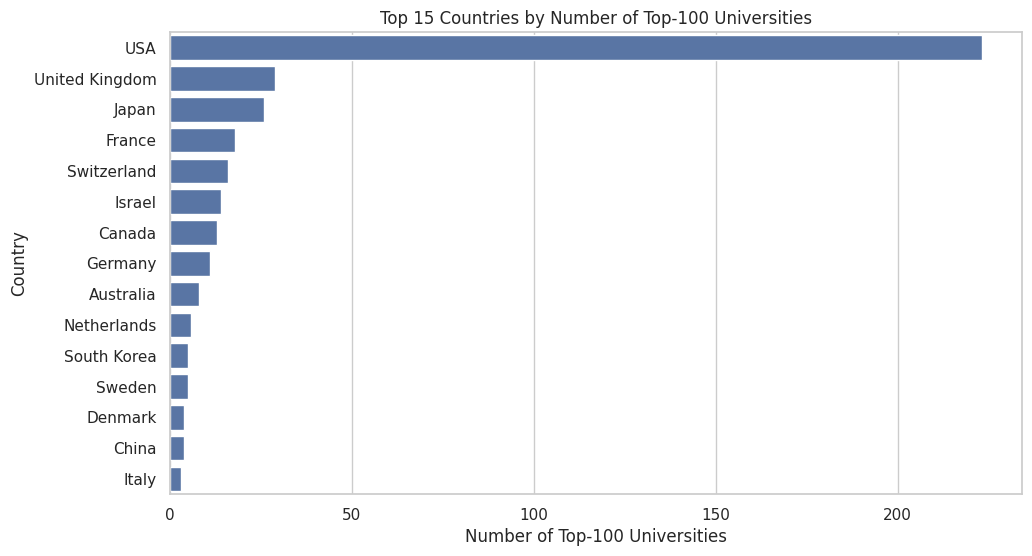

In [ ]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=top100_country_counts.head(15),
    x="top100_count",
    y="country"
)

plt.title("Top 15 Countries by Number of Top-100 Universities")
plt.xlabel("Number of Top-100 Universities")
plt.ylabel("Country")

plt.show()

In [ ]:
country_performance = (
    df.groupby("country")
      .agg(
          university_count=("institution", "nunique"),
          average_world_rank=("world_rank", "mean"),
          best_world_rank=("world_rank", "min")
      )
      .reset_index()
)

country_performance.sort_values(
    "average_world_rank"
).head(20)

,country,university_count,average_world_rank,best_world_rank
43,Singapore,2,101.800000,65
26,Israel,7,181.590909,18
50,Switzerland,9,182.038462,16
33,Netherlands,13,216.862069,84
13,Denmark,5,232.666667,68
49,Sweden,11,246.458333,60
54,USA,231,290.528796,1
20,Hong Kong,6,347.250000,155
35,Norway,5,347.250000,81
46,South Africa,5,361.900000,114


In [ ]:
country_performance_filtered = (
    country_performance[
        country_performance["university_count"] >= 5
    ]
    .sort_values("average_world_rank")
)

country_performance_filtered.head(20)

,country,university_count,average_world_rank,best_world_rank
26,Israel,7,181.590909,18
50,Switzerland,9,182.038462,16
33,Netherlands,13,216.862069,84
13,Denmark,5,232.666667,68
49,Sweden,11,246.458333,60
54,USA,231,290.528796,1
35,Norway,5,347.250000,81
20,Hong Kong,6,347.250000,155
46,South Africa,5,361.900000,114
3,Belgium,10,362.300000,82


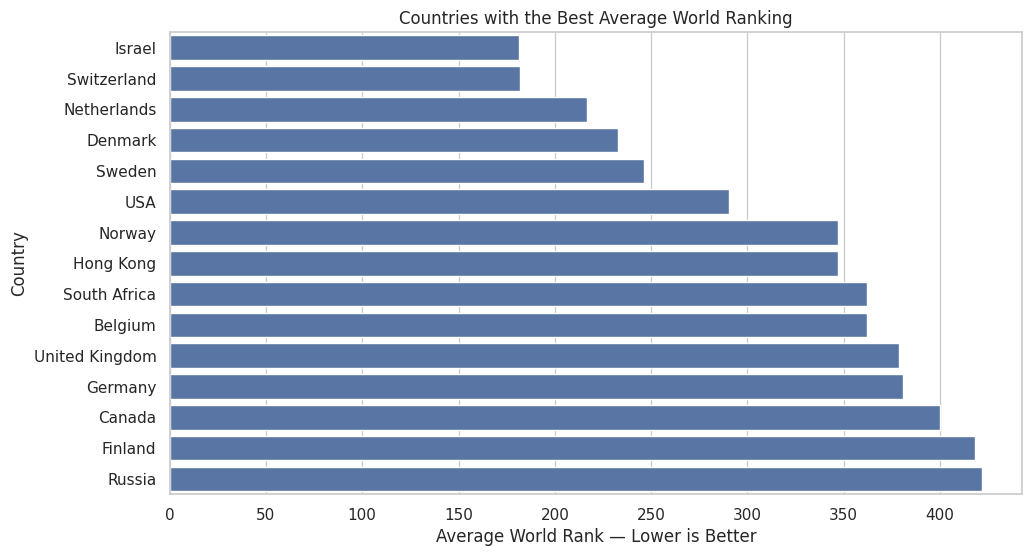

In [ ]:
top_performing_countries = country_performance_filtered.head(15)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_performing_countries,
    x="average_world_rank",
    y="country"
)

plt.title("Countries with the Best Average World Ranking")
plt.xlabel("Average World Rank — Lower is Better")
plt.ylabel("Country")

plt.show()

In [ ]:
countries_to_compare = [
    "India",
    "USA",
    "United Kingdom",
    "Japan",
    "Germany",
    "France",
    "China",
    "Switzerland",
    "Israel"
]

country_comparison = (
    country_performance[
        country_performance["country"].isin(countries_to_compare)
    ]
    .sort_values("average_world_rank")
)

country_comparison

,country,university_count,average_world_rank,best_world_rank
26,Israel,7,181.590909,18
50,Switzerland,9,182.038462,16
54,USA,231,290.528796,1
57,United Kingdom,65,378.458333,3
18,Germany,56,380.730435,67
17,France,54,501.128440,35
28,Japan,74,528.264151,13
23,India,16,638.516129,328
8,China,92,687.616766,55


In [ ]:
india = (
    df[df["country"] == "India"]
    .sort_values(["year", "world_rank"])
)

india[
    [
        "year",
        "institution",
        "world_rank",
        "national_rank",
        "score"
    ]
]

,year,institution,world_rank,national_rank,score
527,2014,Indian Institute of Technology Delhi,328,1,46.10
635,2014,University of Delhi,436,2,45.40
700,2014,Indian Institute of Science,501,3,45.11
734,2014,Indian Institute of Technology Bombay,535,4,45.00
742,2014,Panjab University,543,5,44.97
768,2014,Indian Institute of Technology Kanpur,569,6,44.91
773,2014,Indian Institute of Technology Kharagpur,574,7,44.89
775,2014,Indian Institute of Technology Madras,576,8,44.89
791,2014,Tata Institute of Fundamental Research,592,9,44.83
810,2014,Indian Institute of Technology Roorkee,611,10,44.79


In [ ]:
india = (
    df[df["country"] == "India"]
    .sort_values(["year", "world_rank"])
)

india[
    [
        "year",
        "institution",
        "world_rank",
        "national_rank",
        "score"
    ]
]

,year,institution,world_rank,national_rank,score
527,2014,Indian Institute of Technology Delhi,328,1,46.10
635,2014,University of Delhi,436,2,45.40
700,2014,Indian Institute of Science,501,3,45.11
734,2014,Indian Institute of Technology Bombay,535,4,45.00
742,2014,Panjab University,543,5,44.97
768,2014,Indian Institute of Technology Kanpur,569,6,44.91
773,2014,Indian Institute of Technology Kharagpur,574,7,44.89
775,2014,Indian Institute of Technology Madras,576,8,44.89
791,2014,Tata Institute of Fundamental Research,592,9,44.83
810,2014,Indian Institute of Technology Roorkee,611,10,44.79


In [ ]:
india_yearly = (
    df[df["country"] == "India"]
    .groupby("year")
    .agg(
        university_count=("institution", "nunique"),
        average_world_rank=("world_rank", "mean"),
        best_world_rank=("world_rank", "min")
    )
    .reset_index()
)

india_yearly

,year,university_count,average_world_rank,best_world_rank
0,2014,15,626.133333,328
1,2015,16,650.125000,341


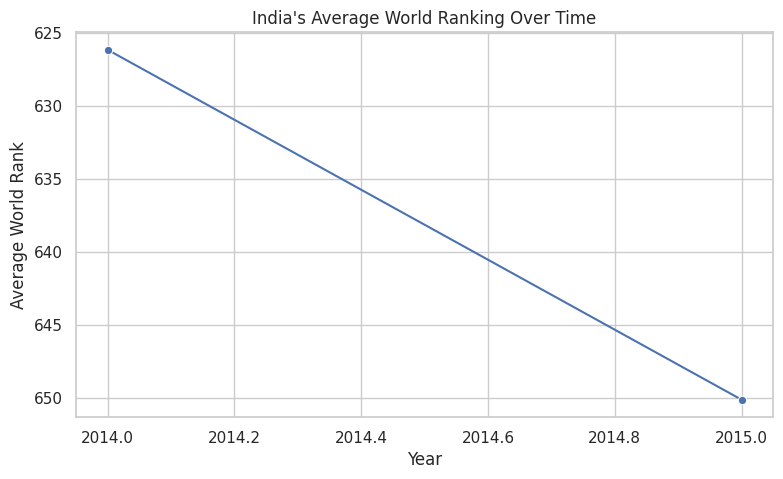

In [ ]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=india_yearly,
    x="year",
    y="average_world_rank",
    marker="o"
)

plt.title("India's Average World Ranking Over Time")
plt.xlabel("Year")
plt.ylabel("Average World Rank")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
india_yearly

,year,university_count,average_world_rank,best_world_rank
0,2014,15,626.133333,328
1,2015,16,650.125000,341


In [ ]:
university_performance = (
    df.groupby("institution")
      .agg(
          years_present=("year", "nunique"),
          average_world_rank=("world_rank", "mean"),
          best_world_rank=("world_rank", "min"),
          average_score=("score", "mean")
      )
      .reset_index()
)

university_performance.sort_values(
    "average_world_rank"
).head(20)

,institution,years_present,average_world_rank,best_world_rank,average_score
184,Harvard University,4,1.00,1,100.0000
511,Stanford University,4,2.25,2,95.2975
312,Massachusetts Institute of Technology,4,3.00,2,94.8375
637,University of Cambridge,4,4.25,4,92.7150
819,University of Oxford,4,5.00,3,92.2125
96,Columbia University,4,6.75,6,90.1550
627,"University of California, Berkeley",4,7.75,7,87.1775
432,Princeton University,4,8.00,6,85.6625
648,University of Chicago,4,9.00,8,83.9275
999,Yale University,4,9.75,8,83.1725


In [ ]:
# Create 2012 vs 2015 ranking comparison
ranking_change = (
    df[df["year"].isin([2012, 2015])]
    .pivot_table(
        index="institution",
        columns="year",
        values="world_rank",
        aggfunc="first"
    )
    .dropna()
)

# Positive = improvement, negative = decline
ranking_change["rank_change"] = (
    ranking_change[2012] - ranking_change[2015]
)

# Biggest improvers
biggest_improvers = (
    ranking_change
    .sort_values("rank_change", ascending=False)
    .head(10)
)

biggest_improvers

year,2012,2015,rank_change
institution,,,
Seoul National University,75.0,24.0,51.0
University of Virginia,84.0,41.0,43.0
University of Pittsburgh - Pittsburgh Campus,71.0,46.0,25.0
École Polytechnique,61.0,36.0,25.0
Rutgers University-New Brunswick,72.0,50.0,22.0
University of Copenhagen,93.0,74.0,19.0
École normale supérieure - Paris,54.0,37.0,17.0
"Pennsylvania State University, University Park",64.0,47.0,17.0
"University of Michigan, Ann Arbor",34.0,19.0,15.0


In [ ]:
top_score_universities = (
    df.groupby("institution")
      .agg(
          years_present=("year", "nunique"),
          average_score=("score", "mean"),
          best_score=("score", "max"),
          average_world_rank=("world_rank", "mean")
      )
      .reset_index()
)

top_score_universities = (
    top_score_universities[
        top_score_universities["years_present"] == 4
    ]
    .sort_values("average_score", ascending=False)
)

top_score_universities.head(20)

,institution,years_present,average_score,best_score,average_world_rank
184,Harvard University,4,100.0000,100.00,1.00
511,Stanford University,4,95.2975,99.09,2.25
312,Massachusetts Institute of Technology,4,94.8375,98.69,3.00
637,University of Cambridge,4,92.7150,97.64,4.25
819,University of Oxford,4,92.2125,97.51,5.00
96,Columbia University,4,90.1550,97.41,6.75
627,"University of California, Berkeley",4,87.1775,92.84,7.75
432,Princeton University,4,85.6625,89.42,8.00
648,University of Chicago,4,83.9275,92.03,9.00
53,California Institute of Technology,4,83.1750,85.50,10.00


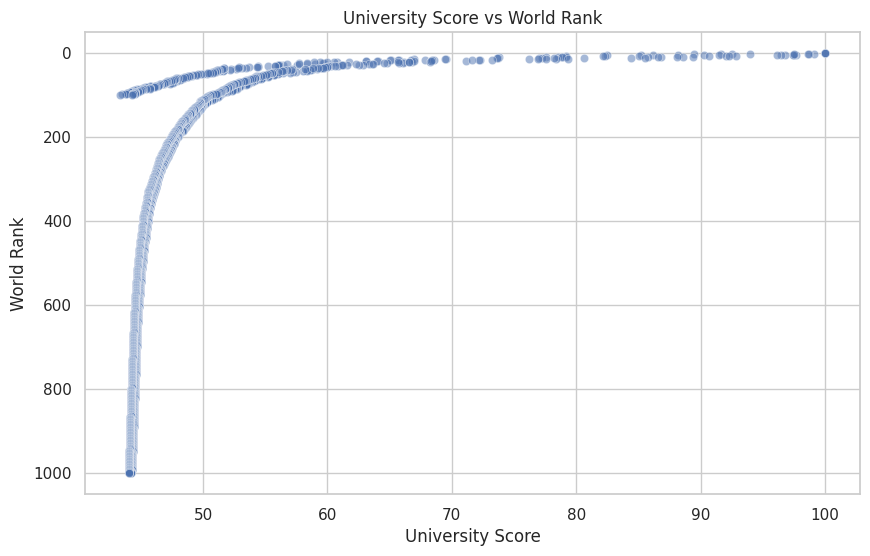

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="score",
    y="world_rank",
    alpha=0.5
)

plt.title("University Score vs World Rank")
plt.xlabel("University Score")
plt.ylabel("World Rank")

# Lower rank is better
plt.gca().invert_yaxis()

plt.show()

In [ ]:
score_rank_corr = df["score"].corr(df["world_rank"])

print(f"Correlation between Score and World Rank: {score_rank_corr:.3f}")

Correlation between Score and World Rank: -0.549


In [ ]:
research_performance = (
    df.groupby("institution")
      .agg(
          years_present=("year", "nunique"),
          avg_publications=("publications", "mean"),
          avg_citations=("citations", "mean"),
          avg_influence=("influence", "mean"),
          avg_patents=("patents", "mean"),
          avg_world_rank=("world_rank", "mean")
      )
      .reset_index()
)

research_performance = (
    research_performance[
        research_performance["years_present"] == 4
    ]
)

research_performance.head(20)

,institution,years_present,avg_publications,avg_citations,avg_influence,avg_patents,avg_world_rank
17,Arizona State University,4,121.50,77.75,91.50,31.00,89.00
42,Boston University,4,55.50,39.50,40.50,140.75,62.25
49,Brown University,4,111.50,79.75,73.75,143.00,76.75
53,California Institute of Technology,4,44.00,20.50,15.25,14.25,10.00
58,Carnegie Mellon University,4,155.00,66.25,165.25,134.25,52.25
96,Columbia University,4,13.25,11.25,11.75,5.75,6.75
100,Cornell University,4,22.50,19.75,17.50,10.00,11.50
109,Dartmouth College,4,173.50,115.75,133.25,76.75,57.00
118,Duke University,4,20.75,14.25,19.50,29.75,26.50
126,Emory University,4,63.25,67.25,50.75,56.75,84.00


In [ ]:
research_performance["research_index"] = (
    research_performance[
        [
            "avg_publications",
            "avg_citations",
            "avg_influence",
            "avg_patents"
        ]
    ].mean(axis=1)
)

research_top = (
    research_performance
    .sort_values("research_index")
    .head(20)
)

research_top

,institution,years_present,avg_publications,avg_citations,avg_influence,avg_patents,avg_world_rank,research_index
184,Harvard University,4,1.00,1.00,1.00,4.25,1.00,1.8125
511,Stanford University,4,5.00,2.50,2.50,10.50,2.25,5.1250
312,Massachusetts Institute of Technology,4,14.50,2.75,2.75,1.00,3.00,5.2500
242,Johns Hopkins University,4,5.75,6.75,8.75,3.50,16.75,6.1875
630,"University of California, Los Angeles",4,5.00,6.75,13.50,11.00,16.25,9.0625
627,"University of California, Berkeley",4,7.75,3.50,4.75,23.00,7.75,9.7500
762,"University of Michigan, Ann Arbor",4,2.75,6.50,18.75,11.25,26.50,9.8125
96,Columbia University,4,13.25,11.25,11.75,5.75,6.75,10.5000
828,University of Pennsylvania,4,8.75,11.00,13.75,16.25,13.25,12.4375
819,University of Oxford,4,11.00,12.50,11.00,18.00,5.00,13.1250


In [ ]:
research_rank_corr = research_performance[
    ["research_index", "avg_world_rank"]
].corr()

research_rank_corr

,research_index,avg_world_rank
research_index,1.000000,0.591586
avg_world_rank,0.591586,1.000000


In [ ]:
correlation = research_performance["research_index"].corr(
    research_performance["avg_world_rank"]
)

print(f"Correlation between Research Index and Average World Rank: {correlation:.3f}")

Correlation between Research Index and Average World Rank: 0.592


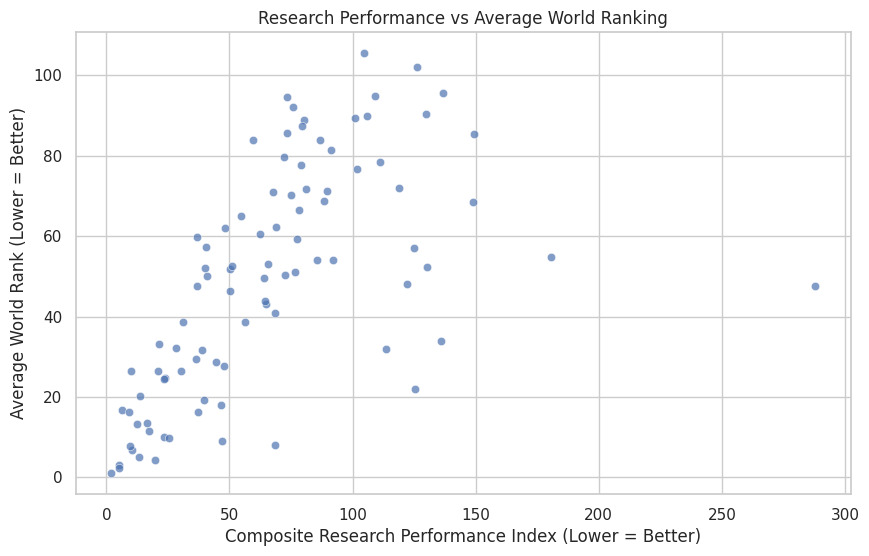

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=research_performance,
    x="research_index",
    y="avg_world_rank",
    alpha=0.7
)

plt.title("Research Performance vs Average World Ranking")
plt.xlabel("Composite Research Performance Index (Lower = Better)")
plt.ylabel("Average World Rank (Lower = Better)")

plt.show()

In [ ]:
research_cols = [
    "avg_publications",
    "avg_citations",
    "avg_influence",
    "avg_patents"
]

research_performance[research_cols].describe()

,avg_publications,avg_citations,avg_influence,avg_patents
count,91.000000,91.000000,91.00000,91.000000
mean,61.486264,59.365385,56.81044,89.173077
std,51.380111,53.456515,42.26123,84.641316
min,1.000000,1.000000,1.00000,1.000000
25%,23.125000,23.750000,23.00000,30.375000
50%,52.250000,50.250000,48.75000,62.500000
75%,85.875000,77.250000,77.37500,129.125000
max,235.750000,335.000000,199.50000,452.500000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

research_cols = [
    "avg_publications",
    "avg_citations",
    "avg_influence",
    "avg_patents"
]

scaler = MinMaxScaler()

normalized = scaler.fit_transform(
    research_performance[research_cols]
)

normalized = 1 - normalized

normalized_df = pd.DataFrame(
    normalized,
    columns=[
        "publications_score",
        "citations_score",
        "influence_score",
        "patents_score"
    ],
    index=research_performance.index
)

normalized_df = normalized_df * 100

research_performance = pd.concat(
    [research_performance, normalized_df],
    axis=1
)

In [ ]:
top_research_universities = (
    research_performance
    .sort_values(
        "research_performance_score",
        ascending=False
    )
    [
        [
            "institution",
            "research_performance_score",
            "avg_world_rank",
            "publications_score",
            "citations_score",
            "influence_score",
            "patents_score"
        ]
    ]
    .head(20)
)

top_research_universities

,institution,research_performance_score,avg_world_rank,publications_score,citations_score,influence_score,patents_score
184,Harvard University,99.820044,1.00,100.000000,100.000000,100.000000,99.280177
511,Stanford University,98.746798,2.25,98.296060,99.550898,99.244332,97.895903
312,Massachusetts Institute of Technology,98.210909,3.00,94.249201,99.476048,99.118388,100.000000
242,Johns Hopkins University,97.949255,16.75,97.976571,98.278443,96.095718,99.446290
627,"University of California, Berkeley",97.403571,7.75,97.124601,99.251497,98.110831,95.127353
630,"University of California, Los Angeles",97.015609,16.25,98.296060,98.278443,93.702771,97.785161
762,"University of Michigan, Ann Arbor",96.598886,26.50,99.254526,98.353293,91.057935,97.729790
96,Columbia University,96.311289,6.75,94.781683,96.931138,94.584383,98.947951
828,University of Pennsylvania,95.975950,13.25,96.698616,97.005988,93.576826,96.622370
819,University of Oxford,95.873506,5.00,95.740149,96.556886,94.962217,96.234773


In [ ]:
world_rank_scaler = MinMaxScaler()

world_rank_normalized = (
    world_rank_scaler.fit_transform(
        research_performance[["avg_world_rank"]]
    )
)

research_performance["overall_rank_score"] = (
    1 - world_rank_normalized
) * 100

In [ ]:
research_performance["research_advantage"] = (
    research_performance["research_performance_score"]
    - research_performance["overall_rank_score"]
)

In [ ]:
research_advantage_top = (
    research_performance
    .sort_values(
        "research_advantage",
        ascending=False
    )
    [
        [
            "institution",
            "research_performance_score",
            "overall_rank_score",
            "research_advantage",
            "avg_world_rank"
        ]
    ]
    .head(20)
)

research_advantage_top

,institution,research_performance_score,overall_rank_score,research_advantage,avg_world_rank
897,University of Texas MD Anderson Cancer Center,74.340597,10.526316,63.814282,94.50
337,Nagoya University,60.454259,0.000000,60.454259,105.50
886,University of Sydney,72.189715,12.679426,59.510289,92.25
126,Emory University,79.059099,20.574163,58.484936,84.00
702,University of Helsinki,61.614360,3.349282,58.265078,102.00
953,University of Zurich,75.753231,18.899522,56.853710,85.75
966,Utrecht University,70.384682,15.311005,55.073678,89.50
17,Arizona State University,68.363324,15.789474,52.573851,89.00
162,Georgia Institute of Technology,67.633650,17.224880,50.408769,87.50
540,"Texas A&M University, College Station",64.755317,14.832536,49.922781,90.00


In [ ]:
research_performance["research_percentile"] = (
    research_performance["research_performance_score"]
    .rank(pct=True)
    * 100
)

research_performance["overall_rank_percentile"] = (
    research_performance["avg_world_rank"]
    .rank(pct=True, ascending=False)
    * 100research_performance["research_percentile_advantage"] = (
    research_performance["research_percentile"]
    - research_performance["overall_rank_percentile"]
)
)

In [ ]:
research_performance["research_percentile_advantage"] = (
    research_performance["research_percentile"]
    - research_performance["overall_rank_percentile"]
)

In [ ]:
research_advantage_percentile = (
    research_performance
    .sort_values(
        "research_percentile_advantage",
        ascending=False
    )
    [
        [
            "institution",
            "research_percentile",
            "overall_rank_percentile",
            "research_percentile_advantage",
            "research_performance_score",
            "avg_world_rank"
        ]
    ]
    .head(20)
)

research_advantage_percentile

,institution,research_percentile,overall_rank_percentile,research_percentile_advantage,research_performance_score,avg_world_rank
833,University of Pittsburgh - Pittsburgh Campus,71.428571,36.263736,35.164835,87.375326,59.75
126,Emory University,50.549451,15.934066,34.615385,79.059099,84.00
897,University of Texas MD Anderson Cancer Center,37.362637,5.494505,31.868132,74.340597,94.50
953,University of Zurich,45.054945,13.186813,31.868132,75.753231,85.75
618,University of British Columbia,63.736264,34.065934,29.670330,84.961271,62.00
886,University of Sydney,32.967033,6.593407,26.373626,72.189715,92.25
968,Vanderbilt University,56.043956,31.868132,24.175824,81.022997,65.00
938,University of Washington - Seattle,87.912088,64.835165,23.076923,94.501171,33.25
628,"University of California, Davis",69.230769,47.252747,21.978022,86.857185,52.00
746,University of Manchester,48.351648,26.373626,21.978022,77.301775,71.00


In [ ]:
overall_advantage = (
    research_performance
    .sort_values(
        "research_percentile_advantage",
        ascending=True
    )
    [
        [
            "institution",
            "research_percentile",
            "overall_rank_percentile",
            "research_percentile_advantage",
            "research_performance_score",
            "avg_world_rank"
        ]
    ]
    .head(20)
)

overall_advantage

,institution,research_percentile,overall_rank_percentile,research_percentile_advantage,research_performance_score,avg_world_rank
186,Hebrew University of Jerusalem,9.890110,78.021978,-68.131868,55.203309,22.00
452,Rockefeller University,7.692308,63.736264,-56.043956,54.409842,34.00
984,Weizmann Institute of Science,12.087912,67.032967,-54.945055,58.246902,32.00
1020,École normale supérieure - Paris,1.098901,55.494505,-54.395604,8.910579,47.50
58,Carnegie Mellon University,4.395604,46.153846,-41.758242,50.651010,52.25
432,Princeton University,51.648352,92.307692,-40.659341,79.380227,8.00
1017,École Polytechnique,2.197802,40.659341,-38.461538,32.033461,54.75
823,University of Paris-Sud,16.483516,53.846154,-37.362637,60.956832,48.00
109,Dartmouth College,6.593407,39.560440,-32.967033,52.189798,57.00
481,Seoul National University,31.868132,60.439560,-28.571429,71.919044,40.75


In [ ]:
research_median = research_performance[
    "research_percentile"
].median()

overall_median = research_performance[
    "overall_rank_percentile"
].median()

print("Research percentile median:", research_median)
print("Overall ranking percentile median:", overall_median)

Research percentile median: 50.54945054945055
Overall ranking percentile median: 50.54945054945055


In [ ]:
def classify_university(row):
    strong_research = row["research_percentile"] >= research_median
    strong_overall = row["overall_rank_percentile"] >= overall_median

    if strong_research and strong_overall:
        return "Strong Research + Strong Overall"
    elif strong_research and not strong_overall:
        return "Research Heavy"
    elif not strong_research and strong_overall:
        return "Overall Ranking Heavy"
    else:
        return "Lower Research + Lower Overall"

research_performance["university_segment"] = (
    research_performance.apply(
        classify_university,
        axis=1
    )
)

In [ ]:
segment_counts = (
    research_performance[
        "university_segment"
    ]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "segment",
    "university_count"
]

segment_counts

,segment,university_count
0,Strong Research + Strong Overall,37
1,Lower Research + Lower Overall,36
2,Research Heavy,9
3,Overall Ranking Heavy,9


In [ ]:
segment_summary = (
    research_performance[
        [
            "institution",
            "research_percentile",
            "overall_rank_percentile",
            "research_performance_score",
            "avg_world_rank",
            "university_segment"
        ]
    ]
    .sort_values(
        [
            "university_segment",
            "research_performance_score"
        ],
        ascending=[True, False]
    )
)

segment_summary.head(30)

,institution,research_percentile,overall_rank_percentile,research_performance_score,avg_world_rank,university_segment
42,Boston University,49.450549,32.967033,78.601310,62.25,Lower Research + Lower Overall
746,University of Manchester,48.351648,26.373626,77.301775,71.00,Lower Research + Lower Overall
591,University of Arizona,46.153846,30.769231,76.122933,66.50,Lower Research + Lower Overall
953,University of Zurich,45.054945,13.186813,75.753231,85.75,Lower Research + Lower Overall
923,University of Utah,43.956044,43.956044,75.166516,53.00,Lower Research + Lower Overall
629,"University of California, Irvine",42.857143,27.472527,75.097365,70.25,Lower Research + Lower Overall
299,Ludwig Maximilian University of Munich,41.758242,20.879121,74.755250,77.75,Lower Research + Lower Overall
673,University of Edinburgh,40.659341,42.307692,74.550647,54.00,Lower Research + Lower Overall
653,University of Colorado Boulder,39.560440,49.450549,74.484221,51.00,Lower Research + Lower Overall
897,University of Texas MD Anderson Cancer Center,37.362637,5.494505,74.340597,94.50,Lower Research + Lower Overall


In [ ]:
print("Research percentile median:",
      research_performance["research_percentile"].median())

print("Overall ranking percentile median:",
      research_performance["overall_rank_percentile"].median())

print("\nSegment counts:")
display(segment_counts)

Research percentile median: 50.54945054945055
Overall ranking percentile median: 50.54945054945055

Segment counts:


,segment,university_count
0,Strong Research + Strong Overall,37
1,Lower Research + Lower Overall,36
2,Research Heavy,9
3,Overall Ranking Heavy,9


In [ ]:
segment_summary = (
    research_performance[
        [
            "institution",
            "research_percentile",
            "overall_rank_percentile",
            "research_performance_score",
            "avg_world_rank",
            "university_segment"
        ]
    ]
    .sort_values(
        "research_percentile",
        ascending=False
    )
)

display(segment_summary.head(30))

,institution,research_percentile,overall_rank_percentile,research_performance_score,avg_world_rank,university_segment
184,Harvard University,100.000000,100.000000,99.820044,1.00,Strong Research + Strong Overall
511,Stanford University,98.901099,98.901099,98.746798,2.25,Strong Research + Strong Overall
312,Massachusetts Institute of Technology,97.802198,97.802198,98.210909,3.00,Strong Research + Strong Overall
242,Johns Hopkins University,96.703297,82.417582,97.949255,16.75,Strong Research + Strong Overall
627,"University of California, Berkeley",95.604396,93.406593,97.403571,7.75,Strong Research + Strong Overall
630,"University of California, Los Angeles",94.505495,84.065934,97.015609,16.25,Strong Research + Strong Overall
762,"University of Michigan, Ann Arbor",93.406593,73.626374,96.598886,26.50,Strong Research + Strong Overall
96,Columbia University,92.307692,94.505495,96.311289,6.75,Strong Research + Strong Overall
828,University of Pennsylvania,91.208791,86.813187,95.975950,13.25,Strong Research + Strong Overall
819,University of Oxford,90.109890,95.604396,95.873506,5.00,Strong Research + Strong Overall


In [ ]:
interactive_df = df.copy()

interactive_df["rank_band"] = pd.cut(
    interactive_df["world_rank"],
    bins=[0, 10, 25, 50, 100, 250, 500, 1000],
    labels=[
        "Top 10",
        "11–25",
        "26–50",
        "51–100",
        "101–250",
        "251–500",
        "501–1000"
    ]
)

interactive_df.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year,rank_band
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012,Top 10
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012,Top 10
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012,Top 10
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012,Top 10
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012,Top 10


In [ ]:
interactive_df[
    [
        "year",
        "institution",
        "country",
        "world_rank",
        "score",
        "rank_band"
    ]
].head(10)

,year,institution,country,world_rank,score,rank_band
0,2012,Harvard University,USA,1,100.00,Top 10
1,2012,Massachusetts Institute of Technology,USA,2,91.67,Top 10
2,2012,Stanford University,USA,3,89.50,Top 10
3,2012,University of Cambridge,United Kingdom,4,86.17,Top 10
4,2012,California Institute of Technology,USA,5,85.21,Top 10
5,2012,Princeton University,USA,6,82.50,Top 10
6,2012,University of Oxford,United Kingdom,7,82.34,Top 10
7,2012,Yale University,USA,8,79.14,Top 10
8,2012,Columbia University,USA,9,78.86,Top 10
9,2012,"University of California, Berkeley",USA,10,78.55,Top 10


In [ ]:
import plotly.express as px

fig = px.scatter(
    interactive_df,
    x="world_rank",
    y="score",
    color="country",
    hover_name="institution",
    hover_data={
        "year": True,
        "country": True,
        "world_rank": True,
        "score": ":.2f",
        "rank_band": True
    },
    animation_frame="year",
    title="Interactive University Ranking Explorer",
    labels={
        "world_rank": "World Rank",
        "score": "University Score"
    },
    height=650
)

fig.update_xaxes(autorange="reversed")

fig.update_layout(
    template="plotly_white",
    legend_title="Country"
)

fig.show()

In [ ]:
country_summary = (
    interactive_df
    .groupby(["year", "country"])
    .agg(
        university_count=("institution", "nunique"),
        average_world_rank=("world_rank", "mean"),
        best_world_rank=("world_rank", "min"),
        average_score=("score", "mean")
    )
    .reset_index()
)

country_summary.head(10)

,year,country,university_count,average_world_rank,best_world_rank,average_score
0,2012,Australia,2,93.000000,92,44.155000
1,2012,Canada,3,47.666667,35,50.963333
2,2012,Denmark,1,93.000000,93,44.150000
3,2012,Finland,1,89.000000,89,44.440000
4,2012,France,5,65.200000,48,47.898000
5,2012,Germany,3,85.000000,82,44.953333
6,2012,Israel,4,36.750000,18,56.155000
7,2012,Italy,1,77.000000,77,46.340000
8,2012,Japan,5,43.200000,14,56.478000
9,2012,Netherlands,2,92.000000,85,44.300000


In [ ]:
fig = px.line(
    country_summary,
    x="year",
    y="average_world_rank",
    color="country",
    markers=True,
    hover_data=[
        "university_count",
        "best_world_rank",
        "average_score"
    ],
    title="Average University World Rank by Country",
    labels={
        "average_world_rank": "Average World Rank",
        "year": "Year",
        "country": "Country"
    }
)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    template="plotly_white",
    height=650
)

fig.show()

In [ ]:
fig = px.line(
    country_summary,
    x="year",
    y="average_world_rank",
    color="country",
    markers=True,
    hover_data=[
        "university_count",
        "best_world_rank",
        "average_score"
    ],
    title="Average University World Rank by Country",
    labels={
        "average_world_rank": "Average World Rank",
        "year": "Year",
        "country": "Country"
    }
)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    template="plotly_white",
    height=650
)

fig.show()

In [ ]:
top_countries = (
    interactive_df["country"]
    .value_counts()
    .head(15)
    .index
)

country_summary_top = country_summary[
    country_summary["country"].isin(top_countries)
].copy()

fig = px.line(
    country_summary_top,
    x="year",
    y="average_world_rank",
    color="country",
    markers=True,
    hover_data=[
        "university_count",
        "best_world_rank",
        "average_score"
    ],
    title="Average University World Rank — Top 15 Countries by Representation",
    labels={
        "average_world_rank": "Average World Rank",
        "year": "Year",
        "country": "Country"
    },
    height=650
)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

In [ ]:
total_universities = interactive_df["institution"].nunique()
total_countries = interactive_df["country"].nunique()
best_rank = interactive_df["world_rank"].min()
average_score = interactive_df["score"].mean()

print("Total Universities:", total_universities)
print("Countries Represented:", total_countries)
print("Best World Rank:", best_rank)
print("Average Score:", round(average_score, 2))

Total Universities: 1024
Countries Represented: 59
Best World Rank: 1
Average Score: 47.8


In [ ]:
fig = px.histogram(
    interactive_df,
    x="world_rank",
    nbins=40,
    title="Distribution of University World Rankings",
    labels={
        "world_rank": "World Rank",
        "count": "University-Year Records"
    },
    height=500
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

In [ ]:
country_counts = (
    interactive_df
    .groupby("country")["institution"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    country_counts,
    x="institution",
    y="country",
    orientation="h",
    title="Top 15 Countries by Number of Universities",
    labels={
        "institution": "Number of Universities",
        "country": "Country"
    },
    height=600
)

fig.update_layout(
    template="plotly_white",
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

In [ ]:
fig = px.scatter(
    interactive_df,
    x="world_rank",
    y="score",
    color="year",
    hover_name="institution",
    hover_data=[
        "country",
        "national_rank",
        "year"
    ],
    title="University Score vs World Rank",
    labels={
        "world_rank": "World Rank",
        "score": "Score"
    },
    height=600
)

fig.update_xaxes(autorange="reversed")

fig.update_layout(
    template="plotly_white"
)

fig.show()